###  Introduction

**Part 1 - EXPLORATORY DATA VISUALIZATION: Ford GoBike Trip Data (Feb 2019) By Idris Isah**


Ford GoBike System Data: This dataset includes information about individual rides made in a bike-sharing system covering the greater San Francisco Bay area.

This Dataset: SF Bay Area bike-share trips, February 2019.


## Preliminary Wrangling

In [6]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [7]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']


In [8]:
df = pd.read_csv("data/201902-fordgobike-tripdata.csv")
print('Shape:', df.shape)
print(df.dtypes)

Shape: (183412, 16)
duration_sec                 int64
start_time                     str
end_time                       str
start_station_id           float64
start_station_name             str
start_station_latitude     float64
start_station_longitude    float64
end_station_id             float64
end_station_name               str
end_station_latitude       float64
end_station_longitude      float64
bike_id                      int64
user_type                      str
member_birth_year          float64
member_gender                  str
bike_share_for_all_trip        str
dtype: object


In [10]:
miss = df.isna().sum()
print(miss[miss > 0])
print('full row duplicates:', df.duplicated().sum())

start_station_id       197
start_station_name     197
end_station_id         197
end_station_name       197
member_birth_year     8265
member_gender         8265
dtype: int64
full row duplicates: 0


In [12]:
for col in ['user_type', 'member_gender', 'bike_share_for_all_trip']:
    print(col)
    print(df[col].value_counts(dropna=False))
    print()

user_type
user_type
Subscriber    163544
Customer       19868
Name: count, dtype: int64

member_gender
member_gender
Male      130651
Female     40844
NaN         8265
Other       3652
Name: count, dtype: int64

bike_share_for_all_trip
bike_share_for_all_trip
No     166053
Yes     17359
Name: count, dtype: int64



In [13]:
print('unique start stations:', df['start_station_id'].nunique())
df['start_time_dt'] = pd.to_datetime(df['start_time'])
print('date range:', df['start_time_dt'].min(), '-', df['start_time_dt'].max())
print('lat range:', df['start_station_latitude'].min(), '-', df['start_station_latitude'].max())
print('lon range:', df['start_station_longitude'].min(), '-', df['start_station_longitude'].max())

unique start stations: 329
date range: 2019-02-01 00:00:20.636000 - 2019-02-28 23:59:18.548000
lat range: 37.3172979 - 37.88022244590679
lon range: -122.45370447635652 - -121.8741186


> **Finding:** 329 stations spanning lat 37.32–37.88, lon -122.45 to -121.87 — that's San Francisco *and* East Bay *and* South Bay, a much larger service area than "SF bike share" implies. Not explored further here (needs a map, out of scope for a 7-plot budget), but noted so station-level claims aren't made later without this context.

In [14]:
print('lowest birth years:', df['member_birth_year'].sort_values().head(10).values)
print('born before 1940:', (df['member_birth_year'] < 1940).sum())

lowest birth years: [1878. 1900. 1900. 1900. 1900. 1900. 1900. 1900. 1900. 1900.]
born before 1940: 203


> **Finding:** a birth year of 1878 implies a 141-year-old rider. Worse, nine rows sit at exactly **1900** — a round number that looks like a placeholder/default rather than real data entry, not organic noise. Any age-based analysis needs a hard filter, not just trimming a long tail.

In [15]:
print('longest durations (s):', df['duration_sec'].sort_values(ascending=False).head(10).values)
print('duration > 24h:', (df['duration_sec'] > 86400).sum())
print('duration > 3h:', (df['duration_sec'] > 10800).sum())

longest durations (s): [85444 84548 83772 83519 83407 83195 82512 82385 81549 80891]
duration > 24h: 0
duration > 3h: 417


> **Finding:** duration never crosses 86,400s (24 hours) — a hard ceiling, which looks like a business rule (auto-return/lockout after 24h) rather than organic trip behavior. Worth knowing before treating the max as a "real" long ride.

In [16]:
df['missing_profile'] = df['member_gender'].isna()
print(pd.crosstab(df['user_type'], df['missing_profile']))
both_missing = (df['member_gender'].isna() & df['member_birth_year'].isna()).sum()
print('missing both gender+birth_year together:', both_missing)

missing_profile   False  True 
user_type                     
Customer          16631   3237
Subscriber       158516   5028
missing both gender+birth_year together: 8265


 >**Finding — the important one:** gender and birth year are missing in the *exact same* 8,265 rows, and missingness is not random across `user_type`: **16.3% of Customer rows** are missing profile data vs. **3.1% of Subscriber rows**. Dropping missing rows globally would strip out Customers at 5x the rate of Subscribers and bias any Subscriber-vs-Customer comparison. Decision: filter missing profile fields *only* within the specific analyses that need them, not globally.


### Wrangling decisions
1. `day_of_week`/`hour` engineered from `start_time`; `day_of_week` kept as an **ordinal** category (Mon→Sun) — several plots below rely on that order and would silently go alphabetical otherwise.
2. `age = 2019 - member_birth_year`; rows with `age > 100` dropped **only** for age-based plots (this also removes the 1900-placeholder rows automatically, since 2019-1900=119).
3. Missing gender/birth_year rows are **not** dropped globally, for the reason above.
4. Station-level/geographic detail is real but out of scope for this notebook.


### Features of interest
`duration_sec`, `age` (derived), `user_type`, `day_of_week` (derived).

### Supporting features
`member_gender`, `hour` (derived) — used as an encoding, not a primary axis; station ids — noted but not plotted.

In [18]:
def load_and_clean(path: str) -> pd.DataFrame:
    """Load raw CSV, parse datetimes, engineer day_of_week (ordinal)/hour/age."""
    df = pd.read_csv(path)
    df['start_time'] = pd.to_datetime(df['start_time'])
    df['end_time'] = pd.to_datetime(df['end_time'])
    df['day_of_week'] = pd.Categorical(df['start_time'].dt.day_name(),
                                        categories=DAY_ORDER, ordered=True)
    df['hour'] = df['start_time'].dt.hour
    df['age'] = 2019 - df['member_birth_year']
    return df

df = load_and_clean('data/201902-fordgobike-tripdata.csv')
df_age_clean = df[df['age'] <= 100].copy()
print('age-clean rows retained:', len(df_age_clean),
      f"({len(df_age_clean)/len(df)*100:.2f}%)")

age-clean rows retained: 175075 (95.45%)


### What is the structure of your dataset?


> The dataset has 183,412 trips and 16 columns. Most are complete; the exceptions
are start/end station id+name (197 missing rows) and member_birth_year / member_gender
(8,265 missing rows each, missing together in exactly the same rows). duration_sec and
bike_id are integers; the station/lat/lon/birth_year fields are floats; user_type,
gender, station names, and the bike-share-for-all flag are strings/categoricals. Two
engineered ordinal/derived fields were added: day_of_week (Monday→Sunday, explicitly
ordered) and hour, both derived from start_time, plus age = 2019 - member_birth_year.

### What is/are the main feature(s) of interest in your dataset?


> duration_sec is the primary feature of interest — it's the thing every question in
this notebook ultimately explains or fails to explain. user_type (Subscriber vs
Customer) turned out to be the strongest driver of it once explored, more so than I
expected going in.

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

> - user_type — the single strongest split found (Subscriber median 490s vs Customer
  median 792s), and it interacts with day_of_week (Customer duration nearly doubles
  on weekends; Subscriber stays flat).
> - day_of_week — supports user_type rather than explaining duration on its own.
> - age — tested directly, but it's a genuine dead end (r=0.0245 with log-duration).
  It's listed here because I checked it, not because it helped.
> - member_gender, hour, station fields — available but deliberately not pursued
  further; gender/birth_year missingness is uneven across user_type (16.3% of
  Customer rows vs 3.1% of Subscriber rows), so any feature built on them needs
  per-analysis filtering rather than a blind global dropna.

**Questions this notebook answers:**

1. What does the trip duration distribution look like, and how skewed is it?

2. Which days of the week generate the most trips?

3. Is rider age related to trip duration?

4. Does trip duration differ by user type (Subscriber vs Customer)?

5. How does mean duration vary across day-of-week x user-type?

6. Does the duration distribution shift by day, split by user type?

7. Do age, duration, and user type show a joint pattern?

## Univariate Exploration


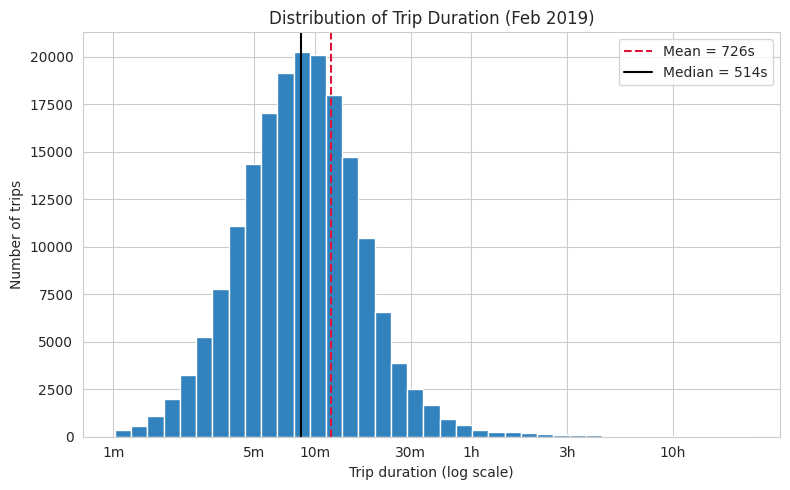

In [19]:
def plot_duration_hist(df, ax=None):
    """Histogram of trip duration (log scale) with mean/median lines annotated."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 5))
    log_dur = np.log10(df['duration_sec'])
    bins = np.linspace(log_dur.min(), log_dur.max(), 40)
    ax.hist(log_dur, bins=bins, color='#3182bd', edgecolor='white')
    ax.axvline(np.log10(df['duration_sec'].mean()), color='crimson', linestyle='--',
               label=f"Mean = {df['duration_sec'].mean():.0f}s")
    ax.axvline(np.log10(df['duration_sec'].median()), color='black', linestyle='-',
               label=f"Median = {df['duration_sec'].median():.0f}s")
    tick_vals = [60, 300, 600, 1800, 3600, 10800, 36000]
    ax.set_xticks(np.log10(tick_vals))
    ax.set_xticklabels(['1m', '5m', '10m', '30m', '1h', '3h', '10h'])
    ax.set_xlabel('Trip duration (log scale)')
    ax.set_ylabel('Number of trips')
    ax.set_title('Distribution of Trip Duration (Feb 2019)')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_duration_hist(df)

> **Q1 answer:** Even on a log axis the distribution is right-skewed. Mean (726s/~12min) sits well above median (514s/~8.5min) — a small share of very long trips (up to ~23.7h) pull the mean up. Most trips cluster around 5–15 minutes: short commute/errand usage, not leisure rentals. **Next:** check whether day of week explains any of this.

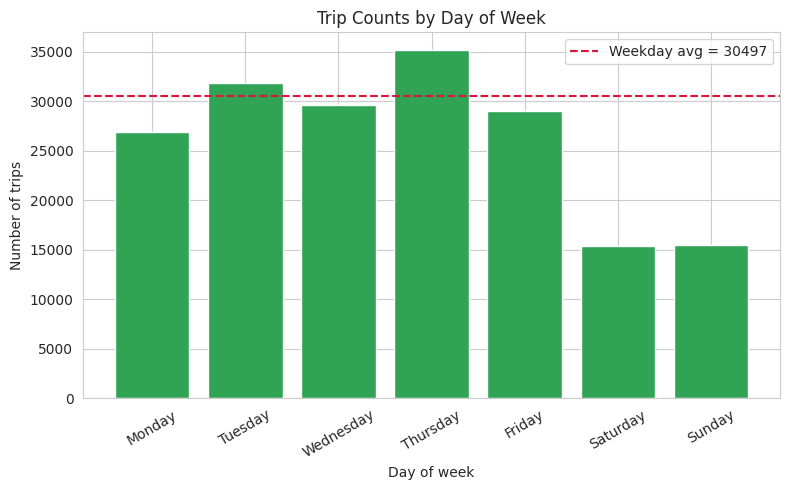

In [21]:
def plot_day_count(df, ax=None):
    """Count plot of trips per day of week, Monday-Sunday order (ordinal)."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 5))
    counts = df['day_of_week'].value_counts().reindex(DAY_ORDER)
    ax.bar(counts.index, counts.values, color='#31a354')
    weekday_mean = counts[DAY_ORDER[:5]].mean()
    ax.axhline(weekday_mean, color='crimson', linestyle='--', label=f'Weekday avg = {weekday_mean:.0f}')
    ax.set_xlabel('Day of week')
    ax.set_ylabel('Number of trips')
    ax.set_title('Trip Counts by Day of Week')
    ax.tick_params(axis='x', rotation=30)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_day_count(df)

>**Q2 answer:** Clear weekday-heavy pattern — weekend volume (~15.4–15.5k) is roughly *half* of any weekday (26.8k–35.2k). Thursday peaks at 35,197. Suggests commuter-driven usage. **Next:** check if `user_type` explains this.

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

> `duration_sec` is extremely right-skewed: median 514s but mean 726s, pulled up by
a long tail running to 85,444s (~23.7 hours). Plotted on a linear axis this is
unreadable — nearly every trip piles into the first bin and the shape is invisible.
I applied a `log10` transform to the x-axis (not to the underlying data — the
mean/median annotations are still computed on raw seconds, then placed at their
log position) and set custom tick labels (1m, 5m, 10m... 3h, 10h) so the axis
stays interpretable in real units rather than raw log values.

> Unusual point: no bar exists past ~24 hours. That ceiling was already flagged
during wrangling (max 85,444s, zero rows above 86,400s) — it shows up again here
as a hard right edge to the histogram rather than a smooth taper, consistent with
an auto-return/lockout rule rather than organic trip behavior.

> `day_of_week` needed no value transformation, but did need an ordering fix: pandas
would otherwise sort it alphabetically (Friday, Monday, Saturday...) which makes
a weekly pattern unreadable. I forced it into an ordered categorical (Monday→Sunday)
before plotting.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

> The two operations in this section were an **axis transform** (log scale for
duration, so skew doesn't hide the shape) and an **ordering fix** (day_of_week
as ordinal, so the plot reads Mon→Sun instead of alphabetically) — not row-level
cleaning. No rows were dropped or filtered for either of these two plots; the
age-based filtering (removing the 72 rows with age > 100) only applies later,
in the bivariate/multivariate sections that actually use `age`. Worth being
explicit about that distinction — it would be sloppy to apply a filter meant for
one variable across the whole dataset by default.

> The `day_of_week` distribution itself was the more unusual find: it's a sharp,
roughly 2x step down from weekday to weekend (Thursday 35,197 vs Saturday
15,405), not a gradual curve — more consistent with two distinct usage regimes
(commute vs. leisure) than with random day-to-day variation.

## Bivariate Exploration

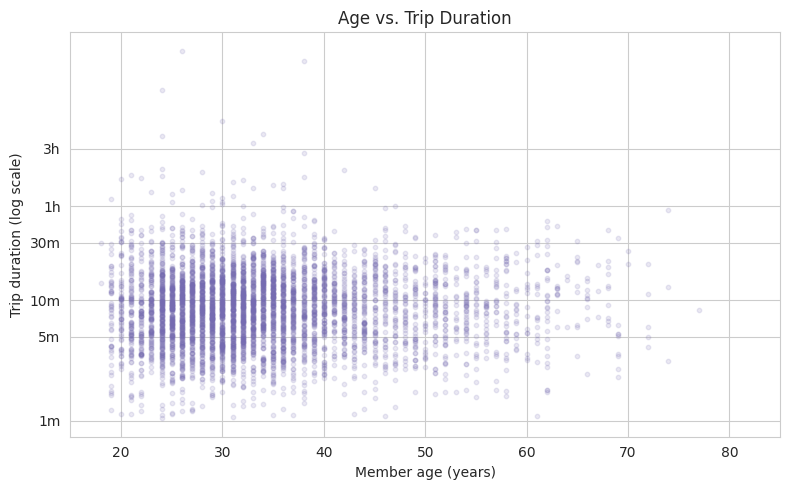

corr age vs log(duration): 0.02445679230532434


In [22]:
def plot_age_duration_scatter(df, ax=None):
    """Scatter of member age vs log trip duration. Sampled + low alpha to
    control overplotting given 175k+ points."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 5))
    sample = df.dropna(subset=['age']).sample(n=min(5000, df['age'].notna().sum()), random_state=42)
    ax.scatter(sample['age'], np.log10(sample['duration_sec']), alpha=0.15, s=10, color='#756bb1')
    tick_vals = [60, 300, 600, 1800, 3600, 10800]
    ax.set_yticks(np.log10(tick_vals))
    ax.set_yticklabels(['1m', '5m', '10m', '30m', '1h', '3h'])
    ax.set_xlabel('Member age (years)')
    ax.set_ylabel('Trip duration (log scale)')
    ax.set_title('Age vs. Trip Duration')
    ax.set_xlim(15, 85)
    plt.tight_layout()
    plt.show()

plot_age_duration_scatter(df_age_clean)
corr = np.corrcoef(df_age_clean['age'], np.log10(df_age_clean['duration_sec']))[0, 1]
print('corr age vs log(duration):', corr)

> **Q3 answer — dead end:** correlation is **0.0245**, essentially zero. Age tells you almost nothing about trip duration in this data, even after removing the placeholder/bad ages. Not reframing this as a "weak positive" — it isn't one. **Next:** check `user_type` instead.

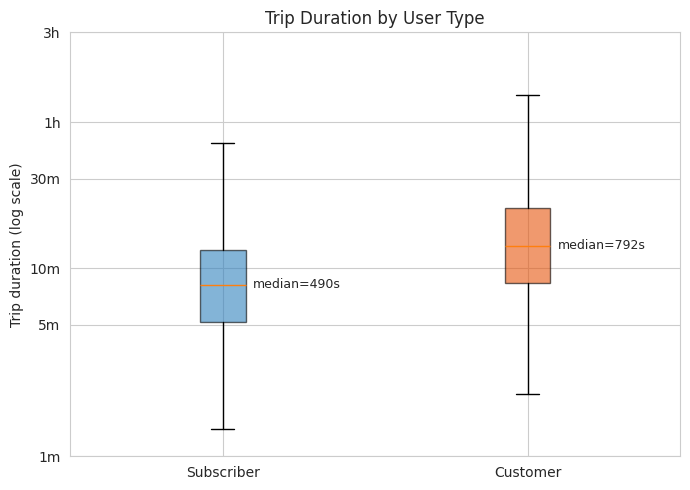

user_type
Customer      792.0
Subscriber    490.0
Name: duration_sec, dtype: float64


In [23]:
def plot_duration_box(df, ax=None):
    """Box plot of log trip duration split by user type, medians annotated."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 5))
    order = ['Subscriber', 'Customer']
    data = [np.log10(df.loc[df['user_type'] == ut, 'duration_sec']) for ut in order]
    bp = ax.boxplot(data, tick_labels=order, showfliers=False, patch_artist=True)
    for patch, color in zip(bp['boxes'], ['#3182bd', '#e6550d']):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    for i, ut in enumerate(order):
        med = df.loc[df['user_type'] == ut, 'duration_sec'].median()
        ax.text(i + 1.1, np.log10(med), f'median={med:.0f}s', va='center', fontsize=9)
    tick_vals = [60, 300, 600, 1800, 3600, 10800]
    ax.set_yticks(np.log10(tick_vals))
    ax.set_yticklabels(['1m', '5m', '10m', '30m', '1h', '3h'])
    ax.set_ylabel('Trip duration (log scale)')
    ax.set_title('Trip Duration by User Type')
    plt.tight_layout()
    plt.show()

plot_duration_box(df)
print(df.groupby('user_type')['duration_sec'].median())

> **Q4 answer:** Yes, clearly. Customer median (792s/13.2min) is **62% higher** than Subscriber median (490s/8.2min). Subscribers behave like commuters; Customers behave more like casual/tourist riders. **Next:** does this gap hold across every day, or does it vary?

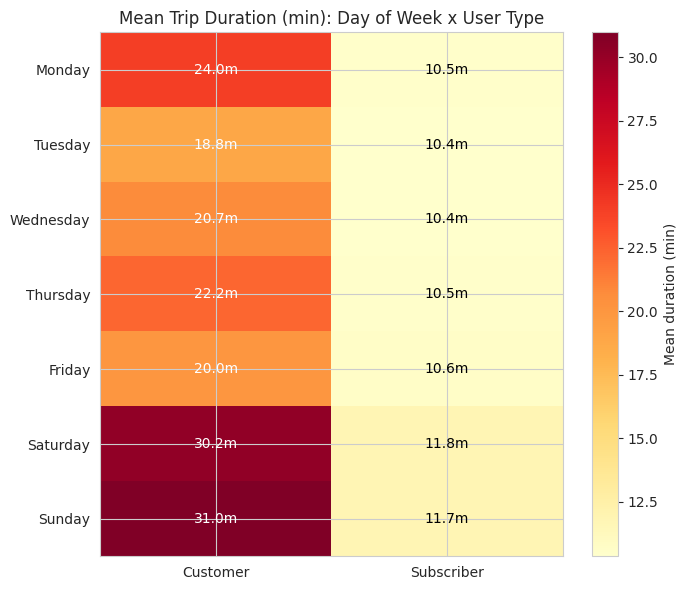

user_type     Customer  Subscriber
day_of_week                       
Monday       24.013693   10.507286
Tuesday      18.824137   10.361898
Wednesday    20.703501   10.367983
Thursday     22.247350   10.521287
Friday       19.993905   10.616126
Saturday     30.197493   11.767530
Sunday       30.971639   11.741488


In [24]:
def plot_duration_heatmap(df, ax=None):
    """Heatmap of mean trip duration (min), day of week x user type, cells annotated."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 6))
    pivot = df.pivot_table(index='day_of_week', columns='user_type', values='duration_sec',
                            aggfunc='mean', observed=False) / 60
    pivot = pivot.reindex(DAY_ORDER)
    im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            ax.text(j, i, f'{val:.1f}m', ha='center', va='center',
                    color='white' if val > pivot.values.mean() else 'black')
    ax.set_title('Mean Trip Duration (min): Day of Week x User Type')
    fig.colorbar(im, ax=ax, label='Mean duration (min)')
    plt.tight_layout()
    plt.show()
    return pivot

pivot_result = plot_duration_heatmap(df)
print(pivot_result)

> **Q5 answer — unexpected, not in the original assumption set:** Customers' mean duration nearly *doubles* on weekends (~30–31 min) vs weekdays (~19–24 min). Subscribers barely move all week (~10.4–11.8 min). This reframes Q2: weekday volume is Subscriber-driven commuting; weekend Customer trips are fewer but much longer — consistent with tourist/leisure use. **Next:** is this a real distribution shift or a mean artifact from a few long weekend trips?

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> `duration_sec` split cleanly by `user_type`: Subscriber median 490s vs Customer
median 792s — a 62% gap. That gap wasn't static either; the heatmap showed
Customer mean duration nearly doubling on weekends (~30-31 min) vs weekdays
(~19-24 min), while Subscriber duration barely moved all week (~10.4-11.8 min).
So `user_type` didn't just shift the average, it changed how much `day_of_week`
mattered at all.

> Against that, `age` showed essentially no relationship with `duration_sec`
(r = 0.0245). That's the one variable I expected to matter and didn't — reporting
it as a real dead end rather than reframing a near-zero number as meaningful.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> Yes — one that duration alone didn't reveal. I checked whether trip *volume*
(not duration) shifts by `user_type` across days, since the univariate section
already showed weekday-heavy overall volume:

> Customer *share* of daily trips roughly doubles on weekends (8-10% weekdays
to 17.8-18.7%). But raw Customer trip counts barely move (~2,400-3,400 every
day, weekday or weekend) — the share shift is really driven by Subscriber
volume collapsing on weekends (from ~25k-32k trips down to ~12.6k), not by
more Customers showing up. So the earlier weekday-heavy pattern from the
univariate section is a Subscriber-specific pattern, not a dataset-wide one;
Customer volume is roughly constant across the whole week, only their trip
*length* changes.

## Multivariate Exploration

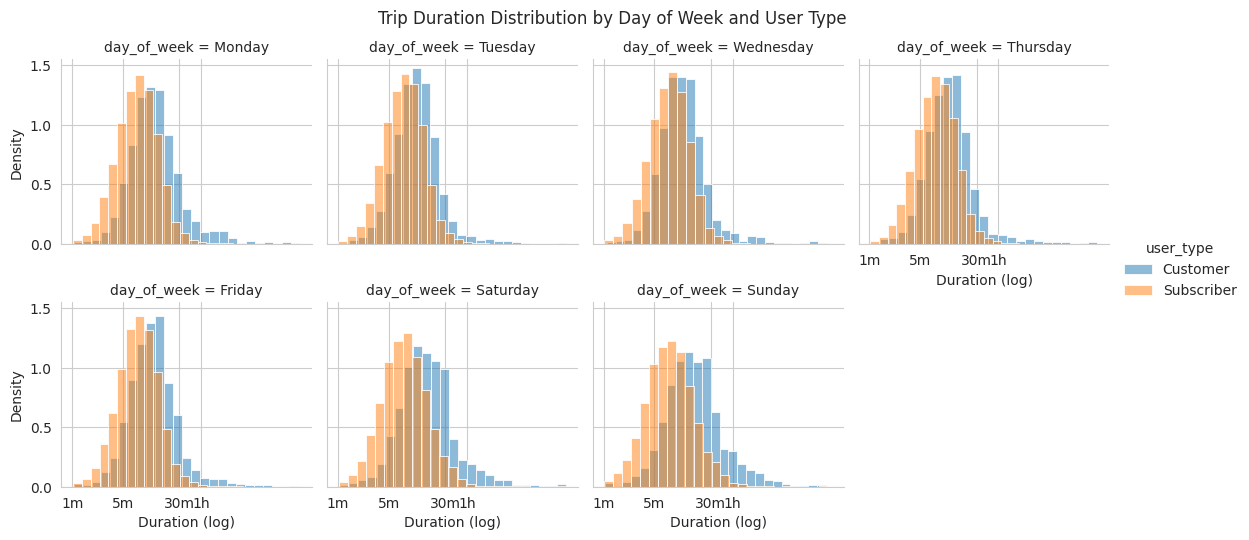

In [25]:
def plot_facet_duration(df):
    """FacetGrid of log-duration densities, one panel per day (Mon->Sun), by user type."""
    df_plot = df.copy()
    df_plot['log_duration'] = np.log10(df_plot['duration_sec'])
    g = sns.FacetGrid(df_plot, col='day_of_week', col_order=DAY_ORDER, col_wrap=4,
                       hue='user_type', height=2.6, aspect=1.1, sharey=True)
    g.map(sns.histplot, 'log_duration', bins=25, stat='density', common_norm=False, alpha=0.5)
    g.add_legend()
    tick_vals = [60, 300, 1800, 3600]
    for ax in g.axes.flat:
        ax.set_xticks(np.log10(tick_vals))
        ax.set_xticklabels(['1m', '5m', '30m', '1h'])
        ax.set_xlabel('Duration (log)')
    g.fig.suptitle('Trip Duration Distribution by Day of Week and User Type', y=1.03)
    plt.show()

plot_facet_duration(df)

> **Q6 answer:** confirms the heatmap wasn't a mean artifact. Subscriber distributions look almost identical across all 7 panels (tight, short-duration peak). Customer distributions visibly widen and shift right on the Sat/Sun panels — a genuine shape change, not just a few outliers dragging the mean. The two groups are behaviorally distinct populations.

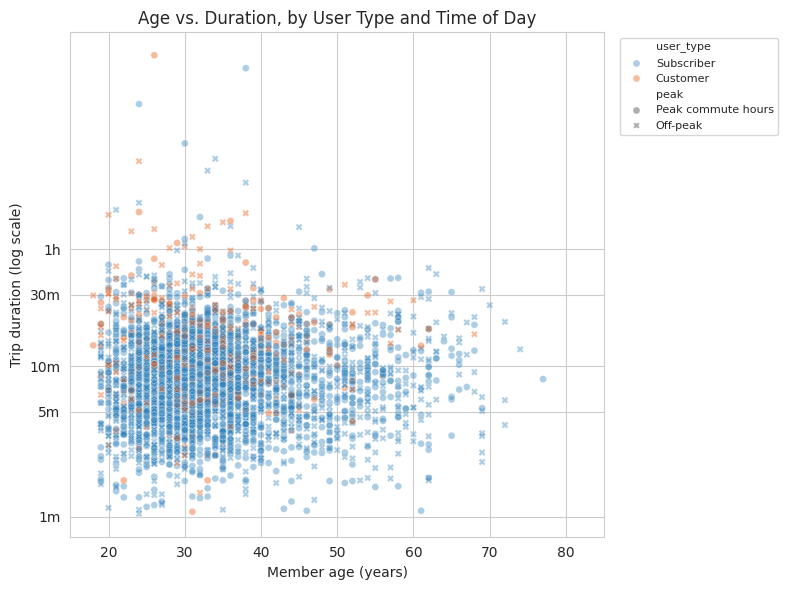

In [26]:
def plot_multivariate_scatter(df, ax=None):
    """Scatter of age vs log duration: color=user_type, marker=peak/off-peak hour."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(8, 6))
    d = df.dropna(subset=['age']).copy()
    d['peak'] = np.where(d['hour'].isin([7, 8, 9, 16, 17, 18, 19]), 'Peak commute hours', 'Off-peak')
    sample = d.sample(n=min(4000, len(d)), random_state=42)
    sample['log_duration'] = np.log10(sample['duration_sec'])
    sns.scatterplot(data=sample, x='age', y='log_duration', hue='user_type', style='peak',
                     alpha=0.4, s=25, ax=ax, palette=['#3182bd', '#e6550d'])
    tick_vals = [60, 300, 600, 1800, 3600]
    ax.set_yticks(np.log10(tick_vals))
    ax.set_yticklabels(['1m', '5m', '10m', '30m', '1h'])
    ax.set_xlim(15, 85)
    ax.set_xlabel('Member age (years)')
    ax.set_ylabel('Trip duration (log scale)')
    ax.set_title('Age vs. Duration, by User Type and Time of Day')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()

plot_multivariate_scatter(df_age_clean)

**Q7 answer:** age still shows no visible trend even split by user_type and time-of-day (confirms Q3's dead end). The clearest separation remains color (user_type) — peak/off-peak marker shapes show no obvious clustering. Age simply isn't a useful axis here, in any combination tried.

In [27]:
df['hour'] = df['start_time'].dt.hour
peak_hours = [7, 8, 9, 16, 17, 18, 19]   # 7-9am, 4-7pm
df['peak'] = np.where(df['hour'].isin(peak_hours), 'Peak', 'Off-peak')

In [28]:
df.groupby(['user_type', 'peak'])['duration_sec'].median()

user_type   peak    
Customer    Off-peak    871.0
            Peak        743.0
Subscriber  Off-peak    469.0
            Peak        504.0
Name: duration_sec, dtype: float64

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

> `user_type` and `day_of_week` strengthened each other rather than just adding up. The bivariate heatmap showed Customer *mean* duration doubling on weekends — but a mean can be dragged by a handful of very long trips, which is exactly the kind of thing this dataset has (up to ~23.7h).
The facet grid resolved that ambiguity: Customer *distributions* visibly widen and shift right on the Sat/Sun panels, while Subscriber distributions stay tight and near-identical across all seven days. So this wasn't a mean artifact — it's a real shape change, and I only know that because the two features were looked at together, not separately.

> `age` did not strengthen anything. Adding `user_type` (color) and peak/off-peak hour (marker) on top of the age-vs-duration scatter still showed no age pattern in either subgroup. Three variables together didn't rescue what two already ruled out — worth stating plainly rather than hunting for an interaction that isn't there.


### Were there any interesting or surprising interactions between features?

> One small but real interaction, checked directly rather than assumed from the scatter alone. 
median duration by `user_type` x peak/off-peak hour:

user_type    peak      median duration
Customer     Off-peak  871s
Customer     Peak      743s
Subscriber   Off-peak  469s
Subscriber   Peak      504s

The direction flips between groups. Subscribers ride slightly *longer* during
peak commute hours than off-peak (504s vs 469s) — consistent with a
somewhat longer, deliberate commute. Customers ride *shorter* during peak hours
(743s vs 871s) — plausibly because a Customer caught in a commute-hour trip is
more likely making a practical point-to-point trip rather than a leisurely one.
The effect is small in absolute terms (tens of seconds), so I'm not overstating
it, but the sign flip between the two groups is a genuine, non-obvious interaction
that wouldn't have surfaced from `user_type` or `hour` alone.

## Conclusions
>**Main findings**
1. Duration is heavily right-skewed (median 514s, mean 726s, capped under 24h); log scale is necessary for any duration plot.
2. Usage is weekday-heavy (Thursday peak 35,197 trips; weekends ~15.4–15.5k), consistent with commuter-driven demand.
3. `user_type` is the strongest behavioral split in the dataset: Subscribers ride short and consistently all week (median 490s); Customers ride longer (median 792s) and their duration nearly *doubles* on weekends — a pattern that only emerged from the day × user_type heatmap and was confirmed, not just assumed, by the facet grid.
4. Age has essentially no relationship with duration (r=0.0245) across every cut tested — reported as a genuine null result.

**Reflection on the process**
- Preliminary wrangling came *before* the questions, not after — the birth-year placeholder values (1878, 1900) and the 24h duration ceiling were found by inspecting the data first, and the missingness-by-user_type finding directly shaped how missing data was handled (per-analysis filtering, not a global drop) rather than being an afterthought.
- Age was a genuine dead end and is reported as one rather than dressed up.
- Station-level/geographic detail (329 stations, 3 regions) was deliberately left unexplored — real, but out of scope for a 7-plot notebook; it would need its own map-based treatment.
